# Variance Swap Replication with NVIDIA Options

This notebook demonstrates how to replicate a variance swap using a portfolio of OTM puts and calls on NVIDIA (NVDA), utilizing real market data.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import glob
import os

# Plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

We load the latest NVIDIA options data and US Treasury rates from the `refinitiv_data` directory.

In [10]:
# Find latest options file
options_files = glob.glob('refinitiv_data/nvda_options_*.csv')
latest_options_file = max(options_files, key=os.path.getctime)
print(f"Loading options data from: {latest_options_file}")

df = pd.read_csv(latest_options_file)

# Find latest rates file
rates_files = glob.glob('refinitiv_data/us_treasury_rates_*.csv')
latest_rates_file = max(rates_files, key=os.path.getctime)
print(f"Loading rates data from: {latest_rates_file}")

rates_df = pd.read_csv(latest_rates_file)

# Display first few rows
display(df.head())
display(rates_df.head())

Loading options data from: refinitiv_data/nvda_options_20260206_220810.csv
Loading rates data from: refinitiv_data/us_treasury_rates_20260214.csv


,Instrument,Implied Volatility,Strike Price,Expiry Date,BID,ASK,CF_LAST,PUTCALLIND
0,NVDAB202619000.U,43.3428,190.0,2026-02-20,4.55,4.60,4.57,CALL
1,NVDAB202618000.U,45.1415,180.0,2026-02-20,10.40,10.45,10.44,CALL
2,NVDAN202618000.U,44.2810,180.0,2026-02-20,3.25,3.30,3.30,PUT
3,NVDAB202618500.U,43.8848,185.0,2026-02-20,7.15,7.25,7.20,CALL
4,NVDAC202620000.U,48.5249,200.0,2026-03-20,7.25,7.35,7.28,CALL


,Instrument,Rate
0,US3MT=RR,3.5975
1,US6MT=RR,3.5025
2,US1YT=RR,3.3025
3,US2YT,3.2500


## 2. Methodology: Variance Swap Replication

A variance swap pays the difference between the realized variance and a fixed strike variance. The payoff at maturity $T$ is:

$$
\text{Payoff} = N_{\text{var}} (\sigma_{\text{realized}}^2 - K_{\text{var}})
$$

The fair value of future variance $K_{\text{var}}$ can be replicated by a static portfolio of OTM options and a dynamic position in the underlying. The theoretical fair variance strike is approximately given by:

$$
E[V] = \frac{2}{T} \left( rT - \left( \frac{S_0 e^{rT}}{S_*} - 1 \right) - \ln \frac{S_*}{S_0} \right) + \frac{2}{T} e^{rT} \left( \int_0^{S_*} \frac{1}{K^2} P(K) dK + \int_{S_*}^\infty \frac{1}{K^2} C(K) dK \right)
$$

Where:
- $T$: Time to maturity
- $r$: Risk-free rate
- $S_0$: Current spot price
- $S_*$: A critical strike price (usually the ATM strike) separating the integration domain for puts and calls
- $P(K)$: Price of a Put option with strike $K$
- $C(K)$: Price of a Call option with strike $K$

### Discretization
In practice, we have a discrete set of strikes. The integral is approximated as a sum:

$$
\int_{0}^{\infty} \frac{1}{K^2} Q(K) dK \approx \sum_i \frac{\Delta K_i}{K_i^2} Q(K_i)
$$

Where $Q(K_i)$ is the price of the OTM option (Put if $K_i < S_*$, Call if $K_i > S_*$).
For the strike $K_i = S_*$, we usually use the average of the Put and Call prices, or simply exclude it if it's perfectly ATM and $S_* = F$.

## 3. Preprocessing

We need to:
1. Select a specific maturity.
2. Calculate Mid Prices ($Mid = (Bid + Ask) / 2$).
3. Determine the relevant risk-free rate.

In [11]:
# 1. Select Maturity
# Let's pick a maturity that has good liquidity, typically around 30 days or the next monthly expiry.
df['Expiry Date'] = pd.to_datetime(df['Expiry Date'])
today = datetime.datetime.now()
df['DaysToMaturity'] = (df['Expiry Date'] - today).dt.days

# Filter for expiries in the future
future_expiries = df[df['DaysToMaturity'] > 0]['Expiry Date'].unique()
# Sort expiries (handle potential DatetimeArray sorting issue)
future_expiries = np.sort(future_expiries)

# Select the expiry closest to 30 days out
target_days = 30
# Ensure calculating with Timestamps
closest_expiry = min(future_expiries, key=lambda x: abs((pd.to_datetime(x) - today).days - target_days))
print(f"Selected Expiry: {pd.to_datetime(closest_expiry).date()}")

df_expiry = df[df['Expiry Date'] == closest_expiry].copy()

# 2. Calculate Mid Price
df_expiry['Mid'] = (df_expiry['BID'] + df_expiry['ASK']) / 2

# Drop rows with missing mid prices
df_expiry = df_expiry.dropna(subset=['Mid'])

# 3. Get Risk-Free Rate
# Map approximate days to rate
days_to_maturity = (pd.to_datetime(closest_expiry) - today).days
T = days_to_maturity / 365.0

# Simple rate selection (can be improved with interpolation)
r_row = pd.DataFrame()
if days_to_maturity <= 90:
    # Use 3M rate
    r_row = rates_df[rates_df['Instrument'].str.contains('US3MT', case=False)]
    maturity_label = "3M"
elif days_to_maturity <= 180:
    # Use 6M rate
    r_row = rates_df[rates_df['Instrument'].str.contains('US6MT', case=False)]
    maturity_label = "6M"
else:
    # Use 1Y rate
    r_row = rates_df[rates_df['Instrument'].str.contains('US1YT', case=False)]
    maturity_label = "1Y"

# Default to a reasonable value if not found
r = 0.045 # Fallback
source = "Fallback"

if not r_row.empty:
    # Identify the correct column for the rate
    if 'Rate' in rates_df.columns:
        r = r_row['Rate'].values[0] / 100.0
        source = f"Rates File ({maturity_label}) - {r_row['Instrument'].values[0]}"
    elif 'CF_LAST' in rates_df.columns:
        r = r_row['CF_LAST'].values[0] / 100.0
        source = f"Rates File ({maturity_label}) - {r_row['Instrument'].values[0]}"

print(f"Time to Maturity (T): {T:.4f} years ({days_to_maturity} days)")
print(f"Risk-Free Rate (r): {r:.2%} [Source: {source}]")

Selected Expiry: 2026-03-20
Time to Maturity (T): 0.0849 years (31 days)
Risk-Free Rate (r): 3.60% [Source: Rates File (3M) - US3MT=RR]


## 4. Identify Forward Price and $S_*$

We estimate the Forward Price $F$ using Put-Call Parity: $C - P = e^{-rT}(F - K)$.
We select the strike $S_*$ closest to the Forward Price (or Spot) to separate Puts and Calls.

In [12]:
# Separate Calls and Puts
# Ensure strikes are rounded to avoid potential float precision mismatch
df_expiry['Strike Price'] = df_expiry['Strike Price'].round(4)

calls = df_expiry[df_expiry['PUTCALLIND'] == 'CALL'].set_index('Strike Price')[['Mid']]
puts = df_expiry[df_expiry['PUTCALLIND'] == 'PUT'].set_index('Strike Price')[['Mid']]

# Merge to find common strikes
merged = calls.join(puts, lsuffix='_call', rsuffix='_put', how='inner')

S_star = None

if not merged.empty:
    # Calculate difference C - P
    merged['diff'] = merged['Mid_call'] - merged['Mid_put']

    # Find absolute minimum difference to identify ATM
    # Theoretically C - P = S_0 - K * e^-rT
    merged['Implied_F'] = np.exp(r * T) * merged['diff'] + merged.index
    
    atm_strike_idx = abs(merged['diff']).idxmin()
    F_est = merged.loc[atm_strike_idx, 'Implied_F']
    print(f"Estimated Forward Price (F) from Parity: ${F_est:.2f}")

else:
    print("Warning: No overlapping strikes for Put-Call Parity.")
    # Fallback: Estimate F from median strike (proxy for ATM)
    F_est = df_expiry['Strike Price'].median()
    print(f"Fallback: Estimating Forward Price (F) as median strike: ${F_est:.2f}")

S0_est = F_est * np.exp(-r * T)
print(f"Estimated Spot Price (S0): ${S0_est:.2f}")

# Select S_star: The first strike below F
strikes = sorted(df_expiry['Strike Price'].unique())
# Handle case where all strikes > F or all < F
below_F = [K for K in strikes if K <= F_est]

if below_F:
    S_star = max(below_F)
else:
    # If no strike <= F, use the lowest strike
    S_star = min(strikes)
    
print(f"S_* (Cutoff Strike): ${S_star}")

Fallback: Estimating Forward Price (F) as median strike: $127.50
Estimated Spot Price (S0): $127.11
S_* (Cutoff Strike): $125.0


## 5. Select OTM Options

We construct the portfolio:
- **Puts** for Strikes $K < S_*$
- **Calls** for Strikes $K > S_*$
- **Average of Put and Call** at $K = S_*$

In [13]:
portfolio_data = []

# Re-separate with fallback if needed (using full df_expiry)
# We iterate over all unique strikes in the expiry
sorted_strikes = sorted(df_expiry['Strike Price'].unique())

for K in sorted_strikes:
    # Get Put/Call price for this strike if available
    call_row = df_expiry[(df_expiry['Strike Price'] == K) & (df_expiry['PUTCALLIND'] == 'CALL')]
    put_row = df_expiry[(df_expiry['Strike Price'] == K) & (df_expiry['PUTCALLIND'] == 'PUT')]
    
    price = None
    type_ = ''
    
    if K < S_star:
        # Use Put
        if not put_row.empty:
            price = put_row.iloc[0]['Mid']
            type_ = 'PUT'
    elif K > S_star:
        # Use Call
        if not call_row.empty:
            price = call_row.iloc[0]['Mid']
            type_ = 'CALL'
    else:
        # At S_star
        if not put_row.empty and not call_row.empty:
            price = (put_row.iloc[0]['Mid'] + call_row.iloc[0]['Mid']) / 2
            type_ = 'AVG'
        elif not put_row.empty:
             price = put_row.iloc[0]['Mid']
             type_ = 'PUT (Only)'
        elif not call_row.empty:
             price = call_row.iloc[0]['Mid']
             type_ = 'CALL (Only)'
            
    if price is not None:
        portfolio_data.append({
            'Strike': K,
            'Price': price,
            'Type': type_
        })

portfolio_df = pd.DataFrame(portfolio_data)
# Calculate Delta K (dK)
# dK_i = (K_{i+1} - K_{i-1}) / 2
# Endpoints need handling, but usually we just take difference with neighbor

if not portfolio_df.empty:
    strikes = portfolio_df['Strike'].values
    dK = np.zeros(len(strikes))

    if len(strikes) > 1:
        for i in range(1, len(strikes)-1):
            dK[i] = (strikes[i+1] - strikes[i-1]) / 2

        # Handle edges (simple approximation)
        dK[0] = strikes[1] - strikes[0]
        dK[-1] = strikes[-1] - strikes[-2]
    else:
        dK[0] = 1.0 # Default if only 1 strike (unlikely to work well)

    portfolio_df['dK'] = dK

    display(portfolio_df.head())
    display(portfolio_df.tail())
else:
    print("No options selected for portfolio.")

,Strike,Price,Type,dK
0,125.0,63.00,CALL (Only),5.0
1,130.0,58.20,CALL,5.0
2,135.0,53.45,CALL,5.0
3,140.0,48.70,CALL,5.0
4,145.0,44.15,CALL,5.0


,Strike,Price,Type,dK
22,270.0,0.175,CALL,10.0
23,280.0,0.120,CALL,10.0
24,290.0,0.080,CALL,25.0
25,330.0,0.020,CALL,40.0
26,370.0,0.010,CALL,40.0


## 6. Calculate Variance Swap Rate

We treat the integral term as the sum of weighted option prices:

$$
\text{Variance Part} = \frac{2}{T} e^{rT} \sum_i \frac{\Delta K_i}{K_i^2} Q(K_i)
$$

In [14]:
if not portfolio_df.empty:
    # Contribution of each option to variance
    portfolio_df['Contribution'] = (2 / T) * np.exp(r * T) * (portfolio_df['dK'] / portfolio_df['Strike']**2) * portfolio_df['Price']

    sigma_squared_options = portfolio_df['Contribution'].sum()

    print(f"Sum of Option Contributions: {sigma_squared_options:.6f}")

    # Log Contract Adjustment (if S_star != F)
    # Term: - (2/T) * ( (S0 * e^rT / S_star - 1) - ln(S0/S_star) ) 
    # Note: Formula usually expects S_star close to Forward. 
    # Correction term for S_star not being exactly F:
    # Variance = OptionSum + (2/T) * (rT - (S0*e^rT / S_star - 1) - ln(S_star/S0))

    log_adjustment = (2 / T) * (r * T - (S0_est * np.exp(r * T) / S_star - 1) - np.log(S_star / S0_est))

    total_variance = sigma_squared_options + log_adjustment
    vol_swap_strike = np.sqrt(total_variance)

    print(f"\n--- Results ---")
    print(f"Log Adjustment Term: {log_adjustment:.6f}")
    print(f"Total Variance (K_var): {total_variance:.6f}")
    print(f"Variance Swap Volatility Strike: {vol_swap_strike:.2%}")
else:
    print("Cannot calculate variance swap rate without portfolio data.")

Sum of Option Contributions: 2.844530

--- Results ---
Log Adjustment Term: -0.004648
Total Variance (K_var): 2.839882
Variance Swap Volatility Strike: 168.52%


## 7. Visualization

Visualizing the weight of options across strikes. The term $\frac{1}{K^2}$ assigns much higher weight to low strikes (OTM Puts), which is why Volatility Skew (high IV for puts) significantly impacts the Variance Swap rate.

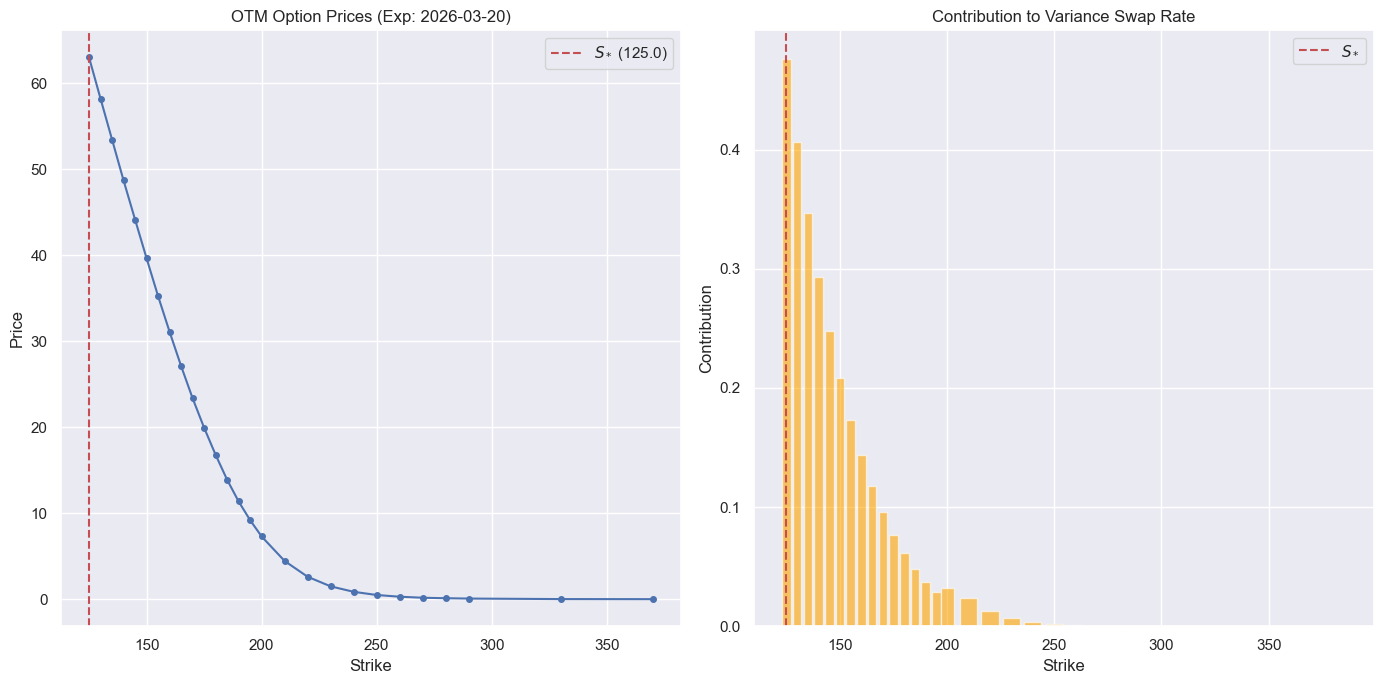

In [15]:
if not portfolio_df.empty:
    plt.figure(figsize=(14, 7))

    # Plot Option Prices
    plt.subplot(1, 2, 1)
    plt.plot(portfolio_df['Strike'], portfolio_df['Price'], marker='o', markersize=4)
    plt.axvline(S_star, color='r', linestyle='--', label='$S_*$' + f' ({S_star})')
    plt.title(f'OTM Option Prices (Exp: {pd.to_datetime(closest_expiry).date()})')
    plt.xlabel('Strike')
    plt.ylabel('Price')
    plt.legend()

    # Plot Variance Contribution
    plt.subplot(1, 2, 2)
    plt.bar(portfolio_df['Strike'], portfolio_df['Contribution'], width=pd.Series(portfolio_df['dK'])*0.8, alpha=0.6, color='orange')
    plt.axvline(S_star, color='r', linestyle='--', label='$S_*$')
    plt.title('Contribution to Variance Swap Rate')
    plt.xlabel('Strike')
    plt.ylabel('Contribution')
    plt.legend()

    plt.tight_layout()
    plt.show()

### Conclusion
The bar chart above shows how much each strike contributes to the total variance. Notice the heavy tail on the left (Puts), illustrating the impact of the skew.